# 2.0-feature-engineering

## Imports

In [1]:
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import pairwise
from recruit_restaurant_visitor_forecasting.config.config import (
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_COL,
    PROCESSED_DATA_DIR,
    RANDOM_SEED,
    PROJ_ROOT,
    HOLIDAY_COL,
    AIR_GENRE_COL
)
from recruit_restaurant_visitor_forecasting.config.features import (
    DAY_OF_WEEK_COL,
    TOTAL_RES_COL,
    VISITORS_NBR_COL,
    VISITORS_DOW,
    RES_VISITORS_DIFF_COL,
    RES_VISITORS_DIFF_NBR_COL,
    GENRE_TE,
    AREA_TE,
    MEAN_PREF,
    MAX_PREF,
    MEDIAN_PREF,
    OPEN_USUALLY_COL,
    MIN_PREF,
    RES_IMPOSSIBILITY_COL,
    AGG_WINDOWS,
    OPENED_RECENTLY_FLG,
    DAYS_FROM_HOL_COL,
    GOLDEN_WEEK_FLG,
    CLOSED_FLG,
    OPEN_DATE_COL,
    DAYS_OF_WEEK
)
from recruit_restaurant_visitor_forecasting.config.preprocessing import (
    VARIANCE_FS_THRESHOLD, TARGET_CORR_THRESHOLD
)
from recruit_restaurant_visitor_forecasting.dataset import standardize_date
from recruit_restaurant_visitor_forecasting.features import (
    drop_first_month,
    select_by_vif,
    get_features_by_variance_threshold,
    get_features_by_target_corr,
    add_open_usually_discr,
    add_open_usually_col_rolling,
    add_open_usually_discr_rolling,
    add_closed_flg
)
from recruit_restaurant_visitor_forecasting.config.feature_names import agg_window_col, agg_exp_col
from recruit_restaurant_visitor_forecasting.plots import plot_corr_matrix, plot_pairs_rel
from recruit_restaurant_visitor_forecasting.utils import (
    get_pairs_by_corr, get_visitors_by_zero_res, get_non_outliers_mask
)
from recruit_restaurant_visitor_forecasting.eda import show_open_usually_stats

2026-05-05 11:56:51.827 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
air_visit_df = pd.read_csv(PROCESSED_DATA_DIR / 'air_visit.csv')
standardize_date(air_visit_df, VISIT_DATE_COL)
standardize_date(air_visit_df, OPEN_DATE_COL)

## Feature correlation

In [3]:
corr = air_visit_df.corr(numeric_only=True)
corr.to_csv(PROJ_ROOT / "reports/tables/correlation_after_clustering.csv")
plot_corr_matrix(corr)

In [4]:
CORRELATION_THRESHOLD = 0.8
get_pairs_by_corr(corr, CORRELATION_THRESHOLD).index.tolist()

[('visitors_mean_7', 'visitors_median_7'),
 ('visitors_mean_7', 'visitors_max_7'),
 ('visitors_mean_7', 'visitors_mean_14'),
 ('visitors_mean_7', 'visitors_median_14'),
 ('visitors_mean_7', 'visitors_mean_28'),
 ('visitors_mean_7', 'visitors_median_28'),
 ('visitors_mean_7', 'res_visitors_diff_mean_7'),
 ('visitors_mean_7', 'res_visitors_diff_mean_14'),
 ('visitors_mean_7', 'res_visitors_diff_mean_28'),
 ('visitors_median_7', 'visitors_mean_14'),
 ('visitors_median_7', 'visitors_median_14'),
 ('visitors_median_7', 'visitors_mean_28'),
 ('visitors_median_7', 'visitors_median_28'),
 ('visitors_median_7', 'res_visitors_diff_mean_7'),
 ('visitors_median_7', 'res_visitors_diff_mean_14'),
 ('visitors_std_7', 'visitors_max_7'),
 ('visitors_std_7', 'visitors_std_14'),
 ('visitors_std_7', 'visitors_max_14'),
 ('visitors_std_7', 'visitors_std_28'),
 ('visitors_max_7', 'visitors_mean_14'),
 ('visitors_max_7', 'visitors_std_14'),
 ('visitors_max_7', 'visitors_max_14'),
 ('visitors_min_7', 'visitor

### Relationship graphs

In [5]:
sample = air_visit_df.sample(10000, random_state=RANDOM_SEED)

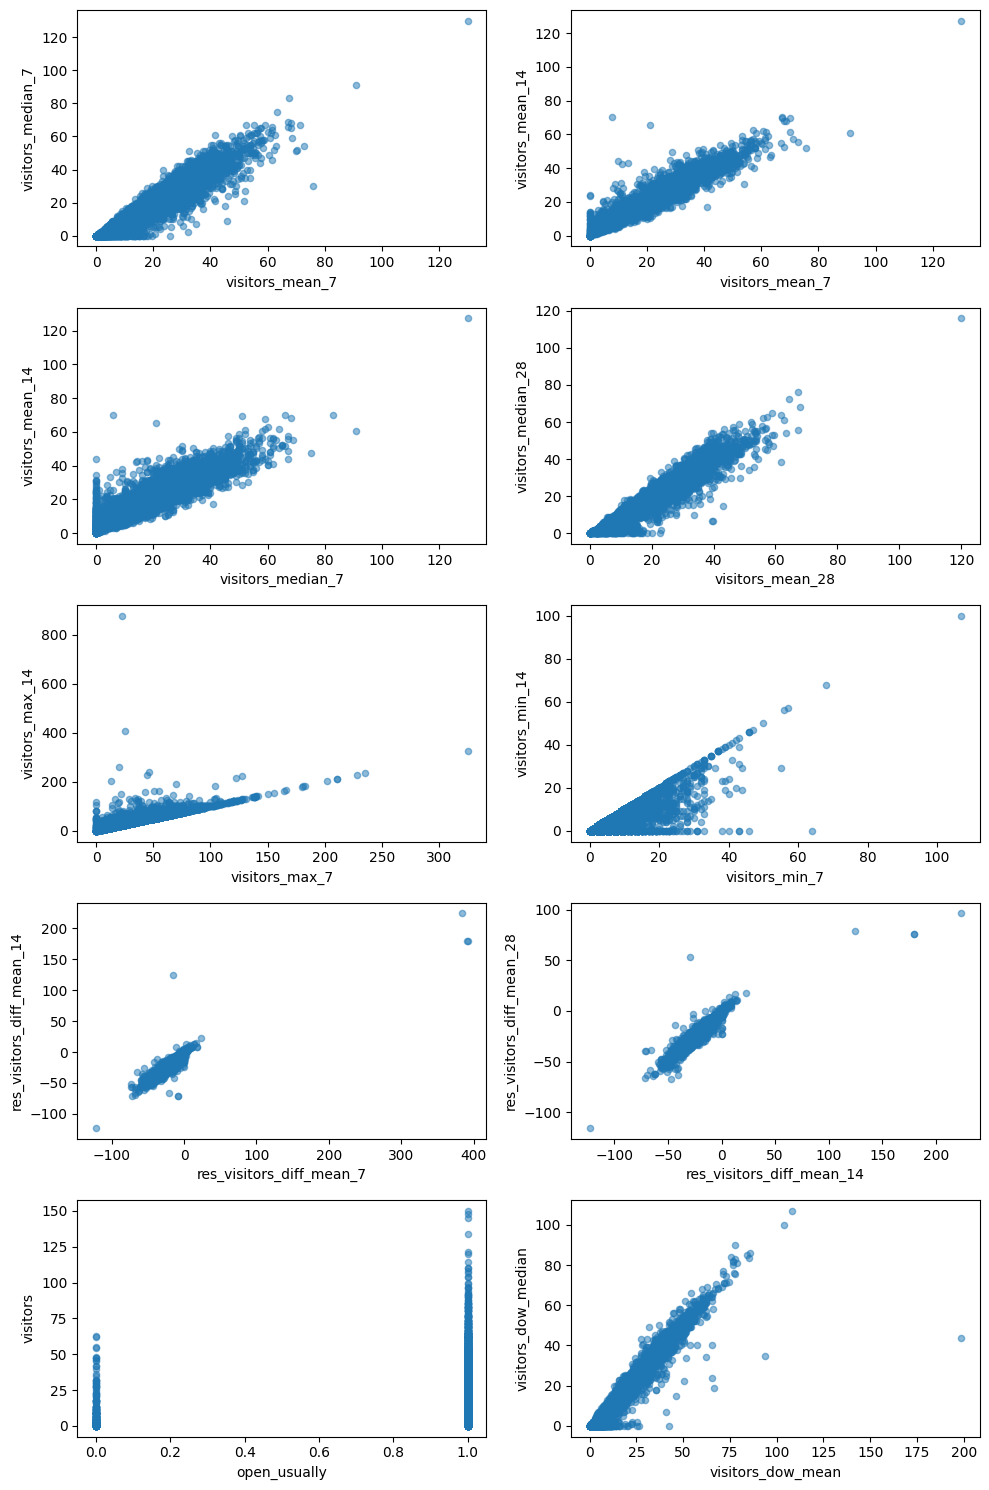

In [6]:
pairs = [
    ((MEAN_PREF, 7), (MEDIAN_PREF, 7)),
    ((MEAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEDIAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEAN_PREF, 28), (MEDIAN_PREF, 28)),
    ((MAX_PREF, 7), (MAX_PREF, 14)),
    ((MIN_PREF, 7), (MIN_PREF, 14))
]
pairs = [
    tuple(agg_window_col(VISITORS_COL, *item) for item in pair) for pair in pairs
]
res_means = [agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, w) for w in AGG_WINDOWS]
pairs += [*pairwise(res_means), (OPEN_USUALLY_COL, VISITORS_COL)]
pairs += [(agg_exp_col(VISITORS_DOW, MEAN_PREF), agg_exp_col(VISITORS_DOW, MEDIAN_PREF))]
plot_pairs_rel(pairs, sample)

Holiday flag feature has approximately the same number of visitors at both 1 and 0, so the feature is uncorrelated and likely unnecessary for the model. Reserve visitors difference mean 14 and visitors have a slightly elongated ellipsoid shape, indicating a relationship between the features.

Among the highly correlated features, the following can be retained: visitors_min_7 as more informative relative to visitors_min_14 (too many zeros can only interfere); max_7 as less noisy relative to max_14 and at the same time equally correlated with the target; mean_14 similarly relative to mean_7, median_7; median_28 similarly relative to mean_28; res_visitors_diff_mean_14 similarly relative to res_visitors_diff_mean_7, res_visitors_diff_mean_28; std_28 as the most correlated with the target and the least correlated with the selected max_14.

Open_usually feature now produces errors much less frequently at values close to zero. However, at higher values, there are still quite a lot of errors (0 visitors), but this is an improvement over the previous version of this feature.

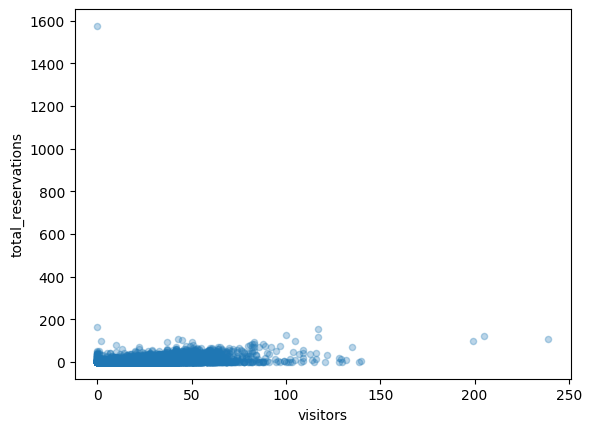

In [7]:
mask = air_visit_df[RES_IMPOSSIBILITY_COL] == 0
sample = air_visit_df[mask].sample(10000, random_state=RANDOM_SEED)
sample.plot.scatter(x=VISITORS_COL, y=TOTAL_RES_COL, alpha=0.3)
plt.show()

In [8]:
air_visit_df[mask][[VISITORS_COL, TOTAL_RES_COL]].corr()

,visitors,total_reservations
visitors,1.000000,0.351285
total_reservations,0.351285,1.000000


Even excluding restaurants for which reservations are impossible, the linear relationship between visitors and reservations is still weak (but the correlation is 0.13 higher than before the exclusion). However, we can see that there is a "boundary" above which the density of values is significantly lower. Situations where there are more reservations than visitors are less common, but not vice versa. There are also quite a few observations where the number of reservations is zero, but there are still many visitors. This isn't related to gaps in air_reserve, as we filled them previously.

## Open usually analysis

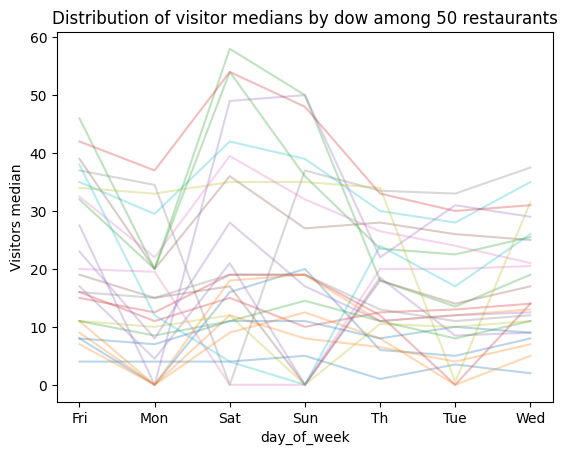

In [9]:
air_visit_df = add_closed_flg(air_visit_df)
opened = air_visit_df[air_visit_df[CLOSED_FLG] == 0]

sampled_restaurants = (
    opened[AIR_RESTAURANT_ID_COL]
    .drop_duplicates()
    .sample(25, random_state=RANDOM_SEED)
)
air_sample = opened[opened[AIR_RESTAURANT_ID_COL].isin(sampled_restaurants)]
dow_median = air_sample.groupby([AIR_RESTAURANT_ID_COL, DAY_OF_WEEK_COL])[
    VISITORS_COL
].median()
dow_median.unstack().T.plot(legend=False, alpha=0.3)
plt.title("Distribution of visitor medians by dow among 50 restaurants")
plt.ylabel("Visitors median")
plt.show()

Above are the visitor medians for a sample of restaurants by day of the week (order was ignored, as we're specifically looking for zeros). While this varies from restaurant to restaurant, there's a consistent pattern: a median of zero indicates the restaurant is likely closed that day - and there are quite a few of them.

### Schedule changes

In [10]:
grouped = air_visit_df.groupby([AIR_RESTAURANT_ID_COL, DAY_OF_WEEK_COL])
vis_rolling = grouped.rolling(4)[VISITORS_COL].median()

In [11]:
vis_rolling.head()

air_store_id          day_of_week    
air_00a91d42b08b08d9  Fri          0      NaN
                                   7      NaN
                                   14     NaN
                                   21    38.5
                                   28    36.5
Name: visitors, dtype: float64

In [12]:
close_to_open = (vis_rolling != 0) & (vis_rolling.shift(1) == 0) & (vis_rolling.notna())
open_to_close = (vis_rolling == 0) & (vis_rolling.shift(1) != 0) & (vis_rolling.shift(1).notna())

In [13]:
close_to_open[close_to_open == True].head()

air_store_id          day_of_week      
air_00a91d42b08b08d9  Mon          206     True
air_0164b9927d20bcc3  Sat          350     True
                                   371     True
air_0241aa3964b7f861  Th           866     True
air_0328696196e46f18  Fri          1105    True
Name: visitors, dtype: bool

In [14]:
close_to_open.sum()

np.int64(2353)

In [15]:
open_to_close[open_to_close == True].head()

air_store_id          day_of_week     
air_00a91d42b08b08d9  Mon          192    True
air_0164b9927d20bcc3  Sat          343    True
                                   364    True
air_0241aa3964b7f861  Th           537    True
                                   908    True
Name: visitors, dtype: bool

In [16]:
open_to_close.sum()

np.int64(2360)

That's a total of about 4,000 cases where the schedule changed (for at least two-thirds times in a row) from open to closed and vice versa. These include both isolated incidents and general restaurant closures on all days of the week. These isolated changes sometimes include closed->open and open->closed (short-term schedule changes).

### Feature versions

In [17]:
discrete_ver = add_open_usually_discr(air_visit_df).sample(10000, random_state=RANDOM_SEED)
dicr_roll = add_open_usually_discr_rolling(air_visit_df, 0.5).sample(10000, random_state=RANDOM_SEED)
continuous_ver = sample
rolling_ver = add_open_usually_col_rolling(air_visit_df).sample(10000, random_state=RANDOM_SEED)

Correlation with visitors: 0.29
Visitor mean on closing days: 1.83.
Visitor mean on opening days: 18.80.


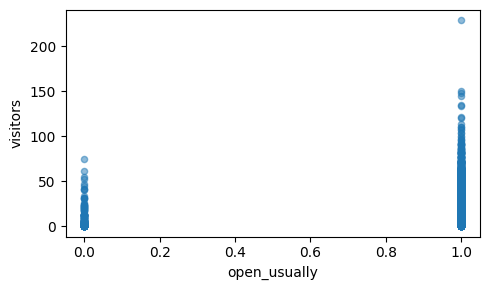

In [18]:
show_open_usually_stats(discrete_ver)

Correlation with visitors: 0.32
Visitor mean on closing days: 2.15.
Visitor mean on opening days: 19.19.


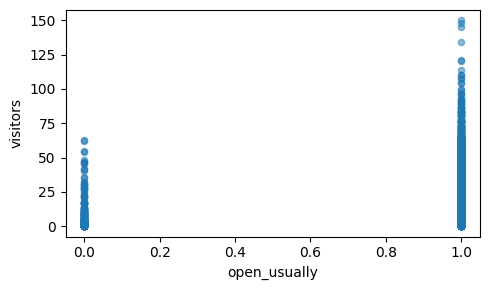

In [19]:
show_open_usually_stats(dicr_roll)

The discrete version of the feature without data leaks is slightly more correlated, but there are still situations where an actual of 0 predicts 1 and vice versa - these situations arise due to rare openings/closings of restaurants on days when the situation is usually different.

Correlation with visitors: 0.27
Visitor mean on closing days: 3.39.
Visitor mean on opening days: 21.41.


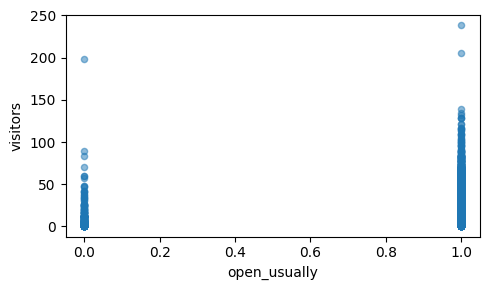

In [20]:
show_open_usually_stats(continuous_ver, 0.5)

The correlation between the continuous feature and the target became stronger. At the same time, the average number of visitors when predicting an closed day has increased (higher False Negatives, but lower False Positives), assuming a threshold of 0.5, though a different threshold may be chosen by the model itself. In this case, False Negatives will probably decrease, but False Positives may increase.

Since open_usually in its new version is correlated with visitors_dow_mean, we can check whether it adds any new information to the target or simply repeats the mentioned feature.

In [21]:
pg.partial_corr(air_visit_df, OPEN_USUALLY_COL, VISITORS_COL, agg_exp_col(VISITORS_DOW, MEAN_PREF))["r"]

pearson    0.054142
Name: r, dtype: float64

Since the partial correlation coefficient (excluding the influence of VISITORS_DOW_MEAN_COL) is practically zero, this feature, compared to VISITORS_DOW_MEAN_COL, does not contribute any new information. Overall, it can be removed in its current form.

Correlation with visitors: 0.37
Visitor mean on closing days: 8.57.
Visitor mean on opening days: 20.33.


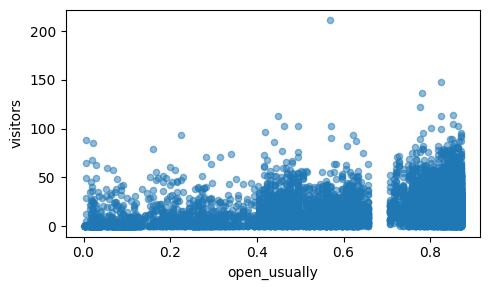

In [22]:
show_open_usually_stats(rolling_ver)

As a result, it is better to take the rolling discrete version of the feature, since its correlation is not much different from the others, there are no data leaks, and the mean of the feature is, in general, good at 0 and 1.

## Correlation difference after clustering

In [23]:
corr_before = pd.read_csv(
    PROJ_ROOT / "reports/tables/correlation_before_clustering.csv",
    index_col=0
)

In [24]:
corr_diff = (corr.abs() - corr_before.abs()).reindex(index=corr.index, columns=corr.columns).round(2)
plot_corr_matrix(corr_diff, 0.5)

City clustering had virtually no effect on the correlation of visitors with the other features. However, initially, the correlation with "neighboring" features was weak (shown previously in the graph). While previously restaurants with a small number of neighbors might have had clear differences in visitor numbers and "neighboring" features, now the effect may be similar but different: large cities outshine small ones. Because of this, "neighboring" features will always be disadvantaged for representatives of small cities, regardless of whether clustering was used. Later we could compare models with clustered and non-clustered cities.

It is also clear that the correlation of various features with std has decreased, which is expected, since after clustering we obtain n cities with a large number of restaurants, and the strong dispersion of small cities is simply leveled out.

## Golden week analysis

### Overall visitors distribution

In [25]:
gw_mask = opened[GOLDEN_WEEK_FLG] == 1
gw = opened[gw_mask]
ngw = opened[~gw_mask]

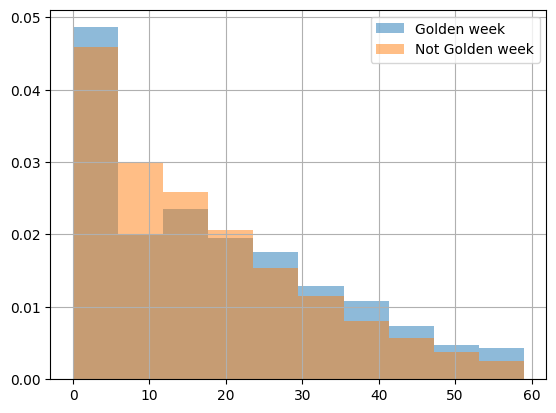

In [26]:
gw_visitors = gw[VISITORS_COL]
visitors_no = get_non_outliers_mask(gw_visitors)
visitors_no_ngw = opened[VISITORS_COL] <= gw_visitors[visitors_no].max()
gw_visitors = gw_visitors[visitors_no]
ngw_visitors = ngw.loc[visitors_no_ngw][VISITORS_COL]

gw_visitors.hist(alpha=0.5, density=True, label="Golden week")
ngw_visitors.hist(alpha=0.5, density=True, label="Not Golden week")
plt.legend()
plt.show()

The two samples are distributed slightly differently. During the golden week, values between 5 and 20 occur less frequently, but values outside this range (especially values greater than 25) occur more frequently.

### Visitors distribution by day of the week

In [27]:
min_gw_date = gw[VISIT_DATE_COL].min()
before_dates = (min_gw_date - pd.Timedelta(days=7), min_gw_date - pd.Timedelta(days=1))
before_gw = opened[opened[VISIT_DATE_COL].between(*before_dates)]

max_gw_date = gw[VISIT_DATE_COL].max()
after_dates = (max_gw_date + pd.Timedelta(days=1), max_gw_date + pd.Timedelta(days=7))
after_gw = opened[opened[VISIT_DATE_COL].between(*after_dates)]

In [28]:
date_periods = {
    "Golden week": gw,
    "Not Golden week": ngw,
}

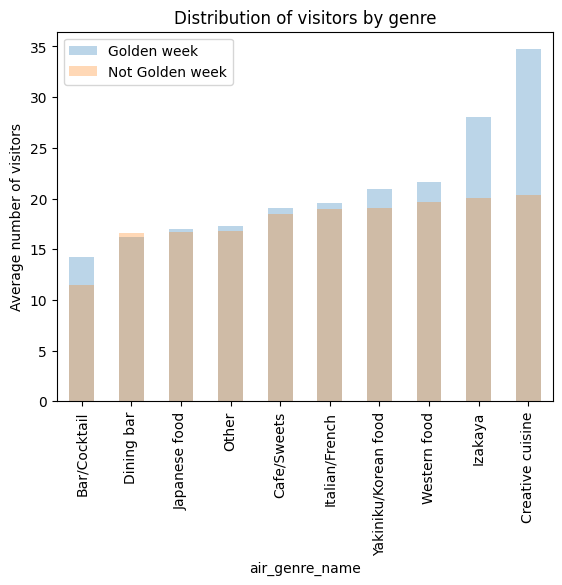

In [29]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (name, df) in enumerate(date_periods.items()):
    distr = df.groupby([AIR_GENRE_COL])[VISITORS_COL].mean().sort_values()
    distr.plot(kind="bar", label=name, alpha=0.3, color=colors[i])

plt.legend()
plt.ylabel("Average number of visitors")
plt.title("Distribution of visitors by genre")
plt.show()

Izakaya (a kind of bar, primarily serving alcohol) and creative cuisine (creative food with elements of other cuisines) are particularly popular during golden week. Other genres are virtually identical (slightly more popular than usual).

In [30]:
date_periods["Week before Golden week"] = before_gw
date_periods["Week after Golden week"] = after_gw

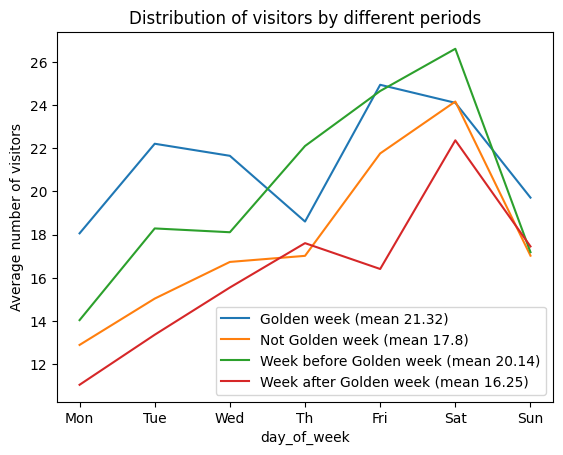

In [31]:
for name, df in date_periods.items():
    distr = df.groupby([DAY_OF_WEEK_COL])[VISITORS_COL].mean()
    distr = distr.reindex(DAYS_OF_WEEK)
    distr.plot(label=f"{name} (mean {distr.mean().round(2)})")

plt.legend()
plt.ylabel("Average number of visitors")
plt.title("Distribution of visitors by different periods")
plt.show()

The average visitor count for golden week and the week before it is significantly higher than for the average week. However, the week after it is the opposite: there are fewer visitors on average than usual. Meanwhile, during golden week, typically unpopular days (Monday and Tuesday) see quite a lot of visitors.

## Removal of features

In [32]:
get_features_by_variance_threshold(air_visit_df, VARIANCE_FS_THRESHOLD)

['golden_week_flg', 'closed']

Golden week flag can be retained because the golden week occurs once later in the test dataset, but it's not guaranteed to have any impact.

In [33]:
possibly_removable_features = get_features_by_target_corr(air_visit_df, TARGET_CORR_THRESHOLD)
possibly_removable_features

['opened_recently',
 'holiday_flg',
 'days_from_holiday',
 'golden_week_flg',
 'air_city_te',
 'air_genre_te',
 'reservation_impossibility_flag',
 'visitors_min_28',
 'visitors_nbrs_mean_7',
 'visitors_nbrs_median_7',
 'visitors_nbrs_std_7',
 'visitors_nbrs_mean_14',
 'visitors_nbrs_median_14',
 'visitors_nbrs_std_14',
 'visitors_nbrs_mean_28',
 'visitors_nbrs_median_28',
 'visitors_nbrs_std_28',
 'visitors_nbrs_lag_1',
 'visitors_nbrs_lag_7',
 'visitors_nbrs_lag_28',
 'visitors_nbrs_dow_std',
 'res_visitors_diff',
 'res_visitors_diff_mean_7',
 'res_visitors_diff_mean_14',
 'res_visitors_diff_mean_28',
 'nbr_res_visitors_diff',
 'nbr_res_visitors_diff_mean_7',
 'nbr_res_visitors_diff_mean_14',
 'nbr_res_visitors_diff_mean_28',
 'closed']

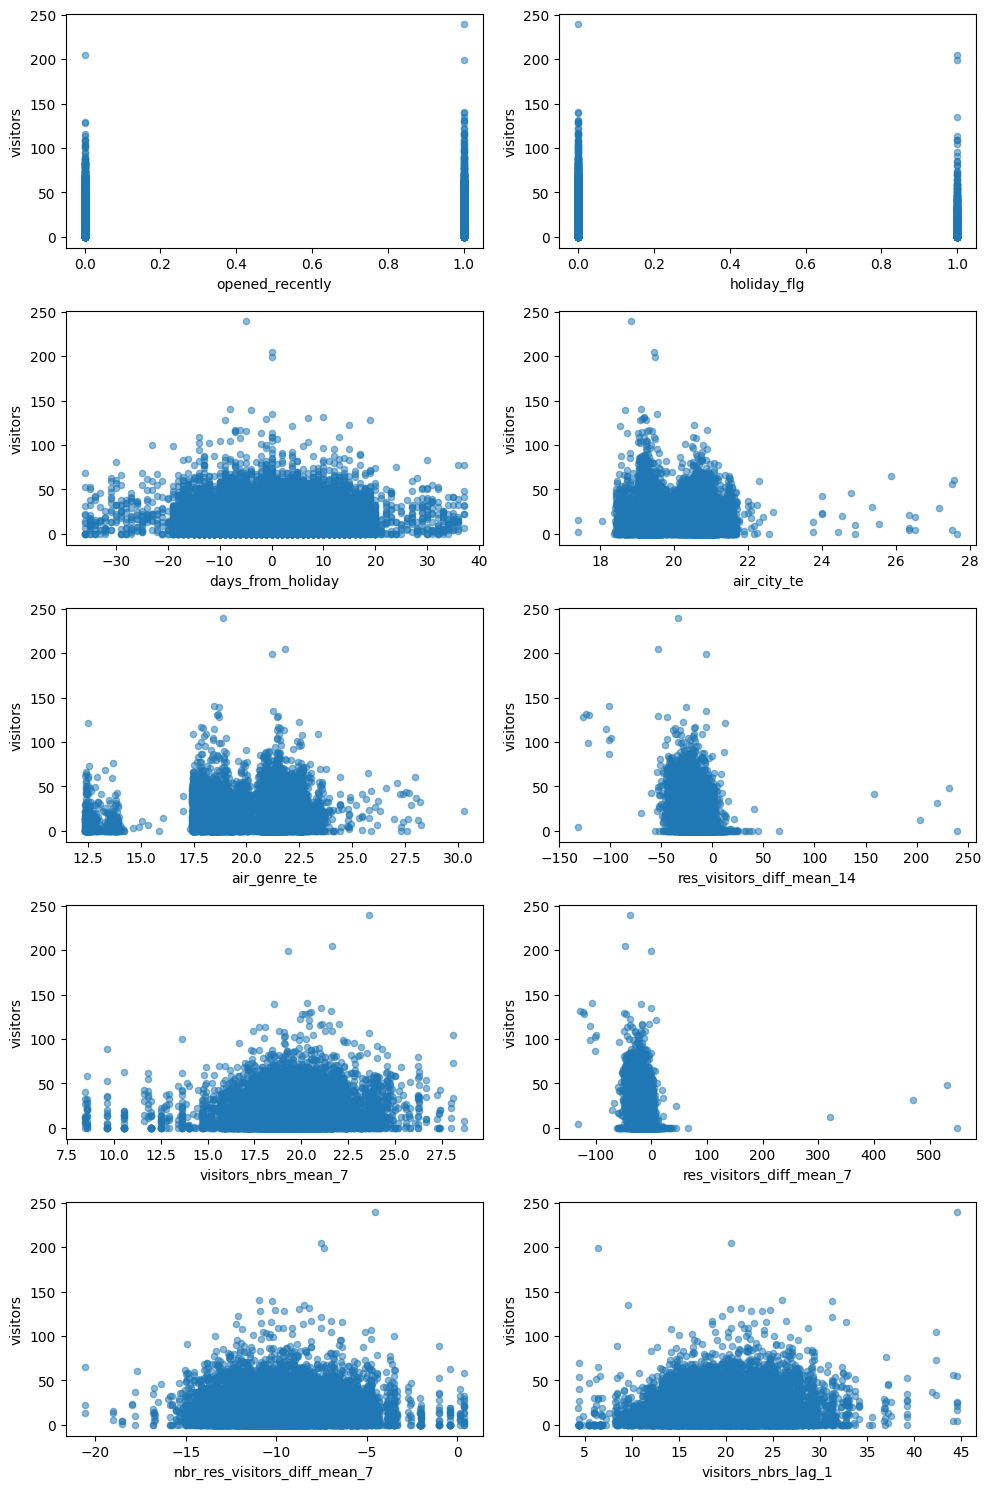

In [34]:
low_correlated_features = [
    OPENED_RECENTLY_FLG,
    HOLIDAY_COL,
    DAYS_FROM_HOL_COL,
    AREA_TE,
    GENRE_TE,
    res_means[1],
    agg_window_col(VISITORS_NBR_COL, MEAN_PREF, 7),
    agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, 7),
    agg_window_col(RES_VISITORS_DIFF_NBR_COL, MEAN_PREF, 7),
    agg_window_col(VISITORS_NBR_COL, "lag", 1),
]
pairs = [(col, VISITORS_COL) for col in low_correlated_features]
plot_pairs_rel(pairs, sample)

There is no linear or nonlinear relationship with any of the above features, so they can be removed. I only looked at the relationship with one of the mean_* features, as the features are correlated.

To determine whether the reservation_impossibility feature is useful, we need to look at records with 0 reservations (as this is precisely the situation for which the feature is designed). If reservation_impossibility and total_reservation are useful, then the distribution is expected to be different for zero reservations.

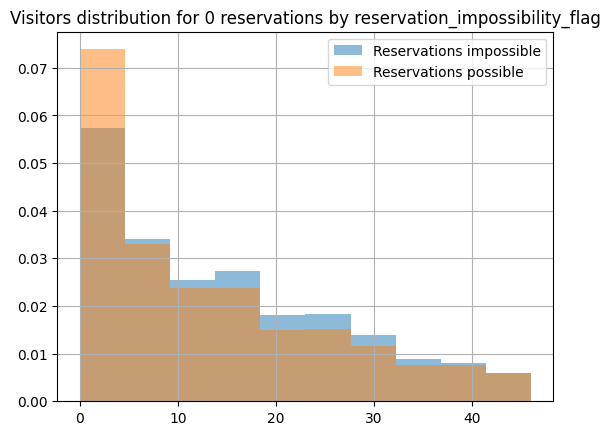

In [35]:
res_imp_visitors = get_visitors_by_zero_res(air_visit_df, True)
res_pos_visitors = get_visitors_by_zero_res(air_visit_df, False)

res_imp_visitors.hist(alpha=0.5, label="Reservations impossible", density=True)
res_pos_visitors.hist(alpha=0.5, label="Reservations possible", density=True)
plt.title(f"Visitors distribution for 0 reservations by {RES_IMPOSSIBILITY_COL}")
plt.legend()
plt.show()

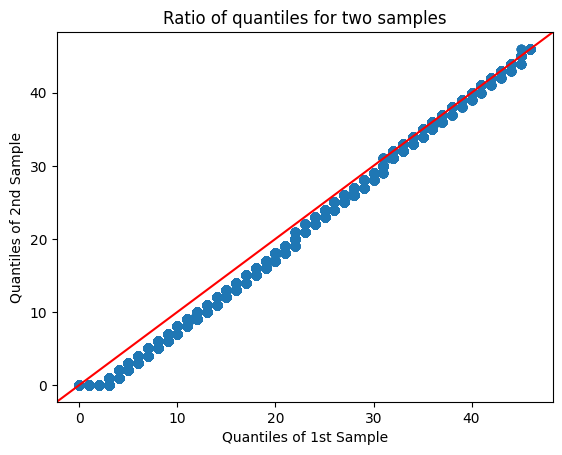

In [36]:
sm.qqplot_2samples(res_imp_visitors, res_pos_visitors, line="45")
plt.title("Ratio of quantiles for two samples")
plt.show()

The distribution of visitors with 0 reservations depend on whether bookings are possible or not. Moreover, it is clear that with 0 bookings, when they are possible, near-zero visitor values appear more often.

In [ ]:
possibly_removable_features.remove(GOLDEN_WEEK_FLG)
removed_features = [*possibly_removable_features, VISITORS_COL, VISITORS_NBR_COL]
features = air_visit_df.drop(columns=removed_features).select_dtypes(include='number')

remaining_cols, drop_order = select_by_vif(
    drop_first_month(air_visit_df).dropna(), features.columns.to_list()
)

In [36]:
print("Remaining columns:", *remaining_cols)

Remaining columns: golden_week_flg open_usually total_reservations total_reservations_nbrs visitors_median_7 visitors_std_7 visitors_min_7 visitors_min_14 visitors_max_28 visitors_min_28 visitors_last_month visitors_lag_1 visitors_lag_7 visitors_lag_28 visitors_nbrs_lag_7 visitors_dow_median visitors_dow_std visitors_dow_std_4


In [37]:
drop_order

visitors_nbrs_dow_mean      1895.630705
visitors_mean_14             390.948655
visitors_max_7               233.128441
visitors_mean_28             194.966386
visitors_std_14              188.049792
visitors_mean_7              147.047138
visitors_dow_mean            145.418638
visitors_dow_mean_4          109.230263
visitors_std_28               68.237661
visitors_nbrs_dow_median      59.000622
visitors_median_14            51.208206
visitors_dow_median_4         24.667654
visitors_max_14               23.869298
visitors_median_28            20.056015
dtype: float64

Those multicollinear features that were not selected after VIF can also be removed.

As a result, features with a weak influence on the target (primarily linear, but also graphically other types) were preliminarily removed. The golden_week_flg feature, although it has very low variance (due to the rarity of the event), was retained because it still tends to have a larger number of visitors than usual.

Features that would theoretically form a pair of influence on the target were tested once – reservation_impossibility and total_reservations. They had no influence in the pair (and, accordingly, the remaining features related to reservations are unlikely to form a pair with reservation_impossibility).

After VIF selection on the remaining features, we have 16 features that are free of multicollinearity and have a normal relationship with the target.

More than half of the developed features (36, to be precise) turned out to be unnecessary. This suggests that we can try to come up with some new combinations, aggregations, and reconsider the approach to creating some features.